In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [3]:
from sklearn.datasets import fetch_openml

In [4]:
mnist = fetch_openml("mnist_784")

In [8]:
X,y = mnist["data"] , mnist["target"]

In [11]:
X = X.to_numpy()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
...     X, y, test_size=0.33, random_state=42)

In [20]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [21]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [30]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [32]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [33]:

perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [37]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=15, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/15
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9020 - loss: 0.3564 - val_accuracy: 0.9004 - val_loss: 0.3625
Epoch 2/15
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9039 - loss: 0.3460 - val_accuracy: 0.9013 - val_loss: 0.3553
Epoch 3/15
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9059 - loss: 0.3381 - val_accuracy: 0.9034 - val_loss: 0.3480
Epoch 4/15
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9076 - loss: 0.3314 - val_accuracy: 0.9047 - val_loss: 0.3429
Epoch 5/15
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9089 - loss: 0.3259 - val_accuracy: 0.9070 - val_loss: 0.3375
Epoch 6/15
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9101 - loss: 0.3211 - val_accuracy: 0.9078 - val_loss: 0.3337
Epoch 7/15
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9112 - loss: 0.3169 - val_accuracy: 0.9091 - val_loss: 0.3302
Epoch 8/15
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9123 - loss: 0.3132 - 

In [38]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [39]:
acc_percp

0.9125108122825623

In [40]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [41]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [42]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=20, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/20
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9259 - loss: 0.2570 - val_accuracy: 0.9562 - val_loss: 0.1505
Epoch 2/20
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9668 - loss: 0.1076 - val_accuracy: 0.9663 - val_loss: 0.1114
Epoch 3/20
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9767 - loss: 0.0740 - val_accuracy: 0.9713 - val_loss: 0.0909
Epoch 4/20
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9815 - loss: 0.0563 - val_accuracy: 0.9721 - val_loss: 0.0909
Epoch 5/20
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9864 - loss: 0.0427 - val_accuracy: 0.9722 - val_loss: 0.0981
Epoch 6/20
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9889 - loss: 0.0342 - val_accuracy: 0.9748 - val_loss: 0.0879
Epoch 7/20
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9910 - loss: 0.0275 - val_accuracy: 0.9727 - val_loss: 0.1066
Epoch 8/20
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9921 - loss: 0.0246 - 

In [43]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [44]:

acc_ann

0.9767532348632812

In [45]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [50]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [51]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [53]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=8, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9800 - loss: 0.0655 - val_accuracy: 0.9866 - val_loss: 0.0406
Epoch 2/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9852 - loss: 0.0515 - val_accuracy: 0.9878 - val_loss: 0.0385
Epoch 3/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9860 - loss: 0.0451 - val_accuracy: 0.9895 - val_loss: 0.0326
Epoch 4/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.9887 - loss: 0.0368 - val_accuracy: 0.9913 - val_loss: 0.0300
Epoch 5/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.9903 - loss: 0.0318 - val_accuracy: 0.9911 - val_loss: 0.0285
Epoch 6/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 65s 44ms/step - accuracy: 0.9912 - loss: 0.0268 - val_accuracy: 0.9913 - val_loss: 0.0308
Epoch 7/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 54s 37ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9912 - val_loss: 0.0308
Epoch 8/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.9936 - loss: 0

In [54]:

acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [55]:

acc_cnn

0.9913420081138611

In [56]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

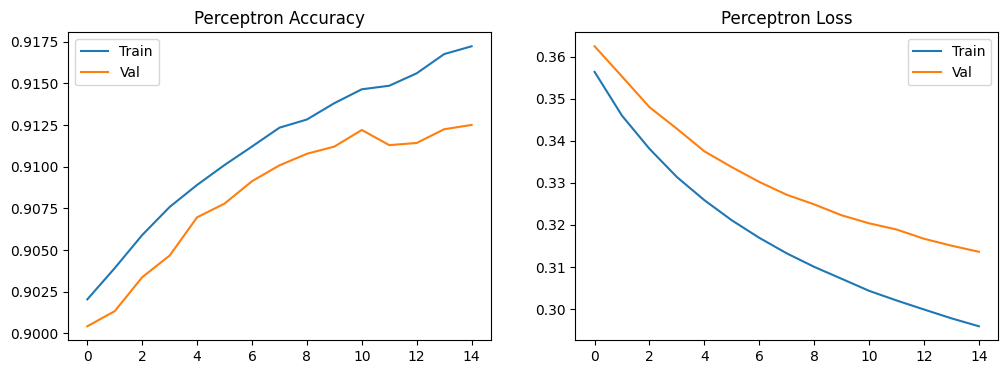

In [57]:
plot_training(history_percp, "Perceptron")

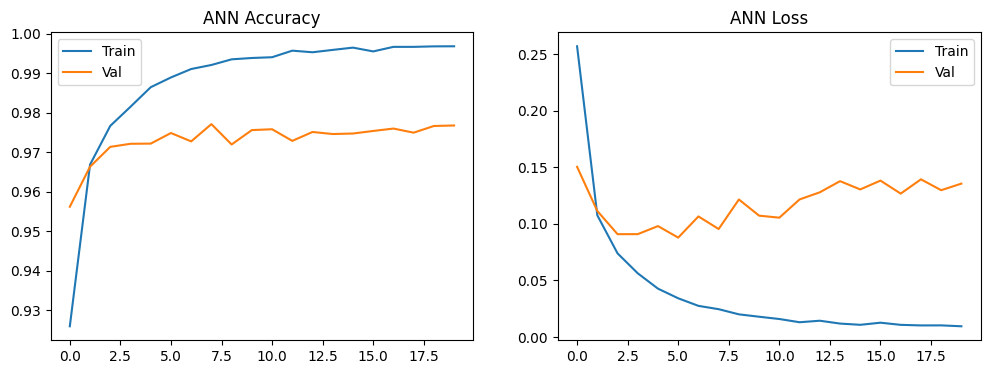

In [58]:
plot_training(history_ann, "ANN")
     

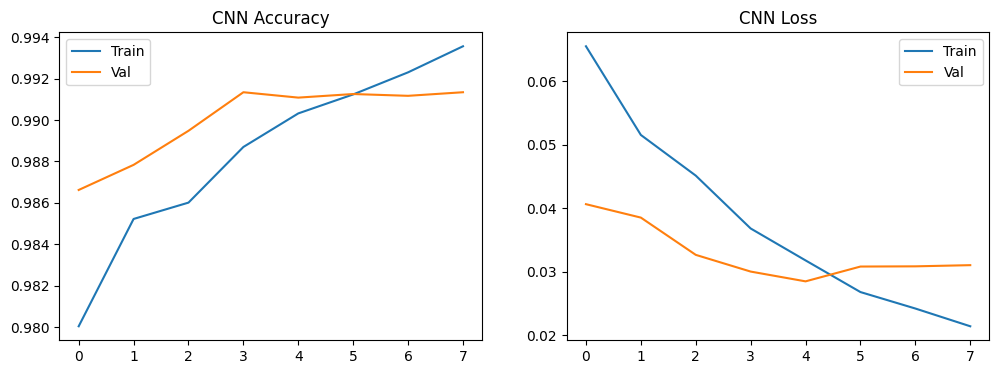

In [59]:

plot_training(history_cnn, "CNN")

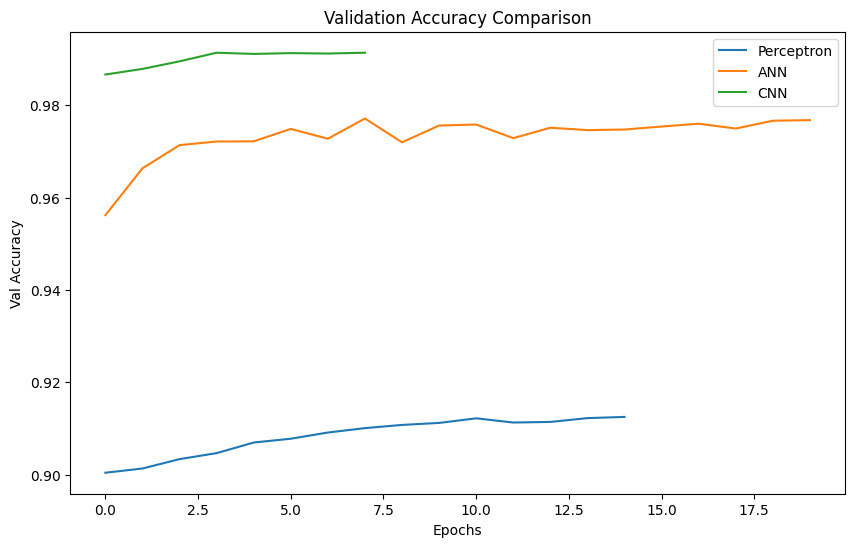

In [60]:

plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

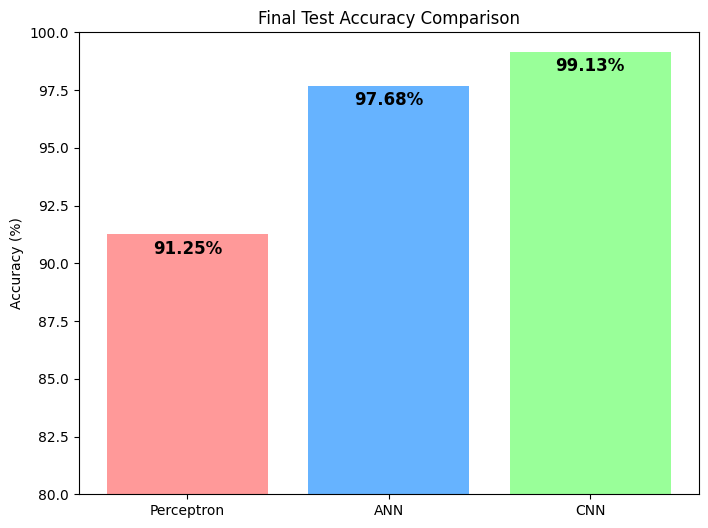

In [66]:
final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()